# sample6 - カスタム Dataset / DataLoader

独自データを PyTorch で扱うための **Dataset** と **DataLoader** を学びます。  
バッチ処理・シャッフル・並列読み込みが簡単に実現できます。

| ステップ | 内容 |
|----------|------|
| 1 | Dataset の基本 |
| 2 | DataLoader でバッチ処理 |
| 3 | カスタム Dataset の作成 |
| 4 | DataLoader を使った学習ループ |

## 1. Dataset の基本

PyTorch の Dataset は `__len__` と `__getitem__` を実装するだけです。

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# TensorDataset: 最もシンプルな Dataset
from torch.utils.data import TensorDataset

X = torch.randn(100, 4)
y = torch.randint(0, 3, (100,))

dataset = TensorDataset(X, y)
print("Dataset 長さ:", len(dataset))
print("1件目:", dataset[0][0].shape, dataset[0][1])

Dataset 長さ: 100
1件目: torch.Size([4]) tensor(1)


## 2. DataLoader でバッチ処理

In [2]:
loader = DataLoader(dataset, batch_size=16, shuffle=True)

print("バッチ数:", len(loader))

for i, (X_batch, y_batch) in enumerate(loader):
    print(f"バッチ {i+1}: X={X_batch.shape}, y={y_batch.shape}")
    if i == 2:
        print("... (省略)")
        break

バッチ数: 7
バッチ 1: X=torch.Size([16, 4]), y=torch.Size([16])
バッチ 2: X=torch.Size([16, 4]), y=torch.Size([16])
バッチ 3: X=torch.Size([16, 4]), y=torch.Size([16])
... (省略)


## 3. カスタム Dataset の作成

実際のプロジェクトでは独自データに合わせた Dataset クラスを作ります。  
アイリスデータを使ったカスタム Dataset の例です。

In [3]:
class IrisDataset(Dataset):
    def __init__(self, transform=None):
        iris = load_iris()
        scaler = StandardScaler()
        self.X = torch.tensor(
            scaler.fit_transform(iris.data), dtype=torch.float32
        )
        self.y = torch.tensor(iris.target, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.transform:
            x = self.transform(x)
        return x, self.y[idx]

full_dataset = IrisDataset()
print("全データ数:", len(full_dataset))

# 学習・検証に分割（8:2）
train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print("学習データ:", len(train_dataset))
print("検証データ:", len(val_dataset))

全データ数: 150
学習データ: 120
検証データ: 30


## 4. DataLoader を使った学習ループ

Epoch [25/100] Train: 0.0426 | Val: 0.1826
Epoch [50/100] Train: 0.0392 | Val: 0.2431
Epoch [75/100] Train: 0.0316 | Val: 0.3375
Epoch [100/100] Train: 0.0286 | Val: 0.4483


/tmp/ipykernel_52474/2973807529.py:51: UserWarning: Glyph 12434 (\N{HIRAGANA LETTER WO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_52474/2973807529.py:51: UserWarning: Glyph 20351 (\N{CJK UNIFIED IDEOGRAPH-4F7F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_52474/2973807529.py:51: UserWarning: Glyph 12387 (\N{HIRAGANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_52474/2973807529.py:51: UserWarning: Glyph 12383 (\N{HIRAGANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_52474/2973807529.py:51: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_52474/2973807529.py:51: UserWarning: Glyph 32722 (\N{CJK UNIFIED IDEOGRAPH-7FD2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_52474/2973807529.py:51: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing f

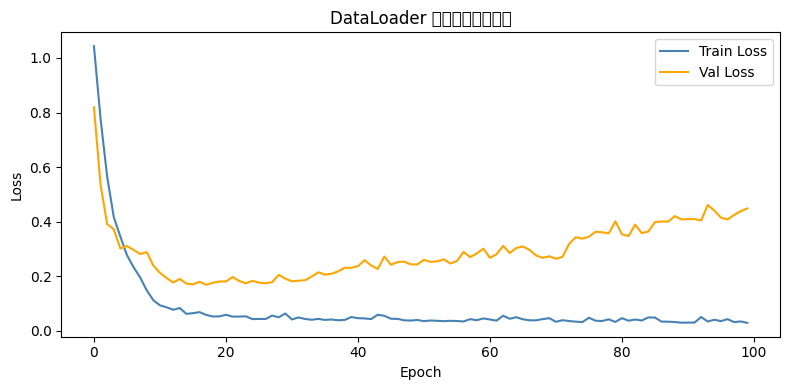

In [4]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = nn.Sequential(
    nn.Linear(4, 16), nn.ReLU(),
    nn.Linear(16, 8), nn.ReLU(),
    nn.Linear(8, 3)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

train_losses, val_losses = [], []

for epoch in range(100):
    # --- 学習 ---
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    # --- 検証 ---
    model.eval()
    batch_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            loss = criterion(model(X_batch), y_batch)
            batch_losses.append(loss.item())
    val_losses.append(np.mean(batch_losses))

    if (epoch + 1) % 25 == 0:
        print(f"Epoch [{epoch+1}/100] Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}")

# 可視化
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses,   label='Val Loss',   color='orange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DataLoader を使った学習曲線")
plt.legend()
plt.tight_layout()
plt.show()